---
title: Regresión logística from scratch
format: 
  html:
    code-fold: false
---

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aavelozb/aavelozb.github.io/blob/main/ejemplos-ml/logreg.ipynb)

Ejemplo con un dataset sencillo de dos dimensiones y dos clases. La idea es tener dos "nubes" de puntos que el modelo deba separar.

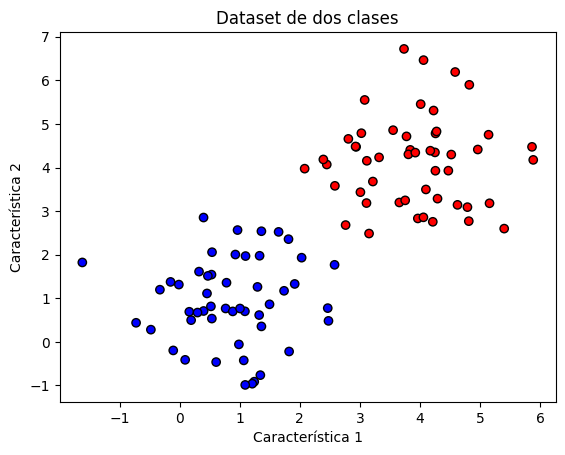

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 100

# clase 0: Normal centrada en (1, 1)
X0 = np.random.randn(n_samples // 2, 2) + np.array([1, 1])
y0 = np.zeros(n_samples // 2)

# clase 1: Normal centrada en (4, 4)
X1 = np.random.randn(n_samples // 2, 2) + np.array([4, 4])
y1 = np.ones(n_samples // 2)

X = np.vstack([X0, X1])
y = np.concatenate([y0, y1])

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.title("Dataset de dos clases")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

## Regresión logística

Implementación de la clase `LogisticRegression` desde cero utilizando Descenso de Gradiente.

Conceptos clave vistos en clases:

- Logit ($t$): La combinación lineal $t = \boldsymbol{X} \boldsymbol{\theta}$.
- Activación Sigmoide: Transforma $t$ en una probabilidad
- Actualización de parámetros: $\boldsymbol{\theta} = \boldsymbol{\theta} - \alpha \nabla J(\boldsymbol{\theta})$, donde $\nabla J$ es el gradiente.
- Función de pérdida, binary cross-entropy: $\ell_{\text{logistic}}(t, y) = - [y \log(h(t)) + (1-y) \log(1-h(t))]$.

In [8]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000, add_bias=True):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.add_bias = add_bias
        self.theta = None
        self.losses = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        if self.add_bias:
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        
        # Descenso de gradiente
        for _ in range(self.n_iter):
            t = np.dot(X, self.theta) # logit: X @ theta
            h = self._sigmoid(t) # hipótesis: h = g(z)
            
            gradient = np.dot(X.T, (h - y)) / n_samples # gradiente: (1/n) * X^T @ (h - y)
            # Nota: Usamos promedio del gradiente para estabilidad
            
            # actualización: theta = theta - alpha * gradiente
            self.theta -= self.lr * gradient
            
            # pérdida: Binary Cross-Entropy
            loss = -np.mean(y * np.log(h + 1e-15) + (1 - y) * np.log(1 - h + 1e-15))
            self.losses.append(loss)

    def predict_prob(self, X):
        if self.add_bias:
            X = np.hstack([np.ones((X.shape[0], 1)), X])
        return self._sigmoid(np.dot(X, self.theta))

    def predict(self, X, threshold=0.5):
        return self.predict_prob(X) >= threshold


### Modelo SIN Bias.

El bias permite que la frontera de decisión se desplace. Sin este término, la frontera de desición siempre debe pasar por el origen $(0,0)$, lo cual limita la capacidad del modelo si los datos están desplazados.

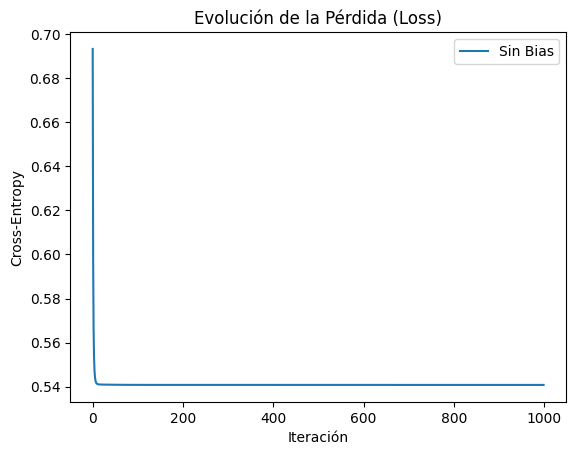

In [9]:
model_no_bias = LogisticRegression(add_bias=False)
model_no_bias.fit(X, y)

# curvas de aprendizaje
plt.plot(model_no_bias.losses, label="Sin Bias")
plt.title("Evolución de la Pérdida (Loss)")
plt.xlabel("Iteración")
plt.ylabel("Cross-Entropy")
plt.legend()
plt.show()

La fontera de decisión es la línea donde $h_{\theta}(x) = 0.5$.

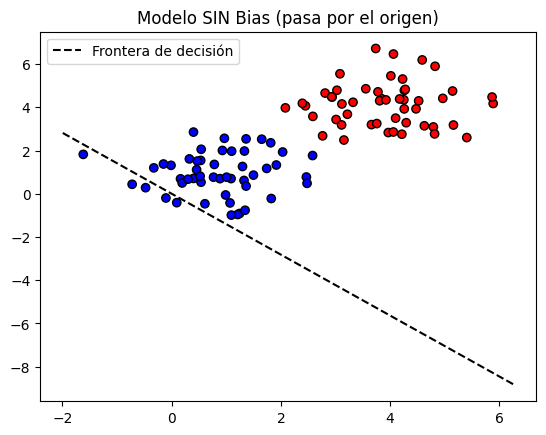

In [10]:
def plot_decision_boundary(X, y, model, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
    ax = plt.gca()
    x_vals = np.array(ax.get_xlim())
    
    if model.add_bias:
        # theta0 + theta1*x1 + theta2*x2 = 0  => x2 = -(theta0 + theta1*x1) / theta2
        y_vals = -(model.theta[0] + model.theta[1] * x_vals) / model.theta[2]
    else:
        # theta0*x1 + theta1*x2 = 0 => x2 = -(theta0*x1) / theta1
        y_vals = -(model.theta[0] * x_vals) / model.theta[1]
        
    plt.plot(x_vals, y_vals, '--k', label="Frontera de decisión")
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(X, y, model_no_bias, "Modelo SIN Bias (pasa por el origen)")


### Modelo CON Bias.

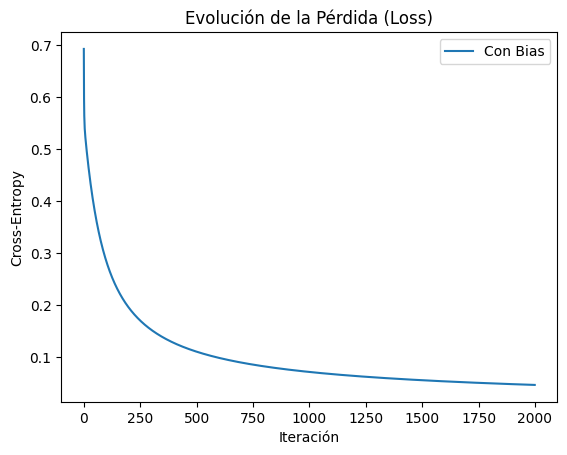

In [11]:
model_with_bias = LogisticRegression(add_bias=True, n_iterations=2000)
model_with_bias.fit(X, y)

# curvas de aprendizaje
plt.plot(model_with_bias.losses, label="Con Bias")
plt.title("Evolución de la Pérdida (Loss)")
plt.xlabel("Iteración")
plt.ylabel("Cross-Entropy")
plt.legend()
plt.show()


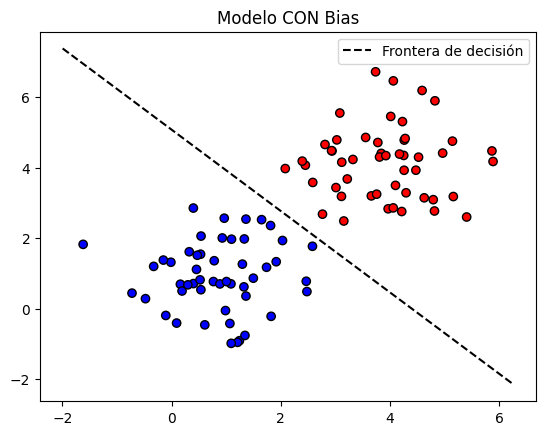

In [12]:
plot_decision_boundary(X, y, model_with_bias, "Modelo CON Bias")